> **Copie versionnée** du notebook d'origine `sante-territoires/notebooks/Private/clustering_methodologie.ipynb`.
> Il produit `data/final/commune_clusters_2023_old.parquet` (reproduit à 100 %).
> Le calcul courant est porté dans `src/pipeline/compute_clustering.py` → `data/final/commune_clusters.parquet`.
> Voir `docs/ChangementMillesime.md` §15.


# Clustering territorial

Méthodologie de clustering K-Means appliquée aux 35 000 communes françaises  
pour l'identification de profils d'accessibilité aux soins.

**Résultat produit :** `data/processed/data/commune/commune_clusters.parquet`

---

## 0. Imports et chemins

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATA_DIR = '../data'
SOURCE_FILE  = f'{DATA_DIR}/processed/score_sante_territoires_final.parquet'
OUTPUT_FILE  = f'{DATA_DIR}/final/commune_clusters_2023_old.parquet'

# Variables de clustering
APL_STD_COLS = [
    'apl_medecins_std', 'apl_dentistes_std', 'apl_infirmiers_std',
    'apl_kines_std', 'apl_sagesfemmes_std'
]
CLUSTER_FEATURES = APL_STD_COLS + ['urbanite_std', 'besoins_std']
N_CLUSTERS = 5

# Poids score APL composite (médecins, dentistes, infirmiers, kinés, sages-femmes)
APL_WEIGHTS = np.array([0.35, 0.15, 0.25, 0.20, 0.05])

## 1. Chargement des données

In [2]:
df = pd.read_parquet(SOURCE_FILE)
print(f"Communes chargées : {len(df):,}")
print(f"Colonnes disponibles : {list(df.columns)}")

Communes chargées : 34,791
Colonnes disponibles : ['code_insee', 'nom_commune', 'latitude', 'longitude', 'population', 'code_dept', 'codes_siren_epci', 'apl_medecins', 'apl_dentistes', 'apl_infirmiers', 'apl_kines', 'apl_sagesfemmes', 'delta_apl_medecins', 'delta_apl_dentistes', 'delta_apl_infirmiers', 'delta_apl_kines', 'delta_apl_sagesfemmes', 'apl_medecins_std', 'apl_dentistes_std', 'apl_infirmiers_std', 'apl_kines_std', 'apl_sagesfemmes_std', 'DENS7', 'LIBDENS7', 'urbanite_std', 'urbanite_std_scaled', 'score_final', 'taux_mortalite_premature', 'mort_premature_std', 'besoins_std', 'score_irdes', 'quintile_irdes']


In [3]:
# Vérification des features de clustering
print("Variables de clustering :")
df[CLUSTER_FEATURES].describe().round(3)

Variables de clustering :


,apl_medecins_std,apl_dentistes_std,apl_infirmiers_std,apl_kines_std,apl_sagesfemmes_std,urbanite_std,besoins_std
count,34774.000,34774.000,34774.000,34774.000,34774.000,34738.000,34791.000
mean,-0.000,-0.000,0.000,-0.000,-0.000,-0.575,-0.000
std,1.000,1.000,1.000,1.000,1.000,0.429,1.000
min,-2.253,-1.507,-1.787,-1.571,-1.762,-1.000,-2.244
25%,-0.636,-0.730,-0.625,-0.665,-0.665,-0.700,-0.813
50%,-0.056,-0.123,-0.187,-0.207,-0.067,-0.700,-0.098
75%,0.569,0.588,0.441,0.445,0.595,-0.300,0.618
max,28.255,6.843,23.269,12.558,18.916,1.000,2.406


In [4]:
# Valeurs manquantes
missing = df[CLUSTER_FEATURES].isna().sum()
print("Valeurs manquantes par variable :")
print(missing)

Valeurs manquantes par variable :
apl_medecins_std       17
apl_dentistes_std      17
apl_infirmiers_std     17
apl_kines_std          17
apl_sagesfemmes_std    17
urbanite_std           53
besoins_std             0
dtype: int64


## 2. Préparation de la matrice de features

Toutes les variables sont déjà sur la même échelle (z-score).  
K-Means étant sensible à l'échelle, aucune normalisation supplémentaire n'est nécessaire.

Les communes avec des valeurs manquantes sur une variable sont exclues du clustering  
(stratégie de suppression de ligne).

In [5]:
df_clean = df.dropna(subset=CLUSTER_FEATURES).copy()
X = df_clean[CLUSTER_FEATURES].values

print(f"Communes après suppression NaN : {len(df_clean):,}")
print(f"Communes exclues (NaN)         : {len(df) - len(df_clean):,}")
print(f"Shape matrice X                : {X.shape}")

Communes après suppression NaN : 34,729
Communes exclues (NaN)         : 62
Shape matrice X                : (34729, 7)


## 3. Choix du nombre de clusters k

Deux critères sont utilisés pour sélectionner k :
- **Méthode du coude (elbow)** : inertie intra-cluster en fonction de k
- **Score de silhouette** : mesure de la cohésion et de la séparation des clusters

In [6]:
# Note : calcul sur un sous-échantillon pour accélérer l'exploration
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=min(10_000, len(X)), replace=False)
X_sample = X[sample_idx]

k_range = range(2, 11)
inertias  = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels, sample_size=3000, random_state=42))
    print(f"k={k} | inertie={km.inertia_:,.0f} | silhouette={silhouettes[-1]:.4f}")

k=2 | inertie=42,245 | silhouette=0.2955


k=3 | inertie=36,583 | silhouette=0.1880


k=4 | inertie=32,782 | silhouette=0.1828


k=5 | inertie=30,500 | silhouette=0.1558


k=6 | inertie=28,931 | silhouette=0.1548


k=7 | inertie=27,384 | silhouette=0.1484


k=8 | inertie=26,257 | silhouette=0.1439


k=9 | inertie=25,116 | silhouette=0.1391


k=10 | inertie=24,105 | silhouette=0.1414


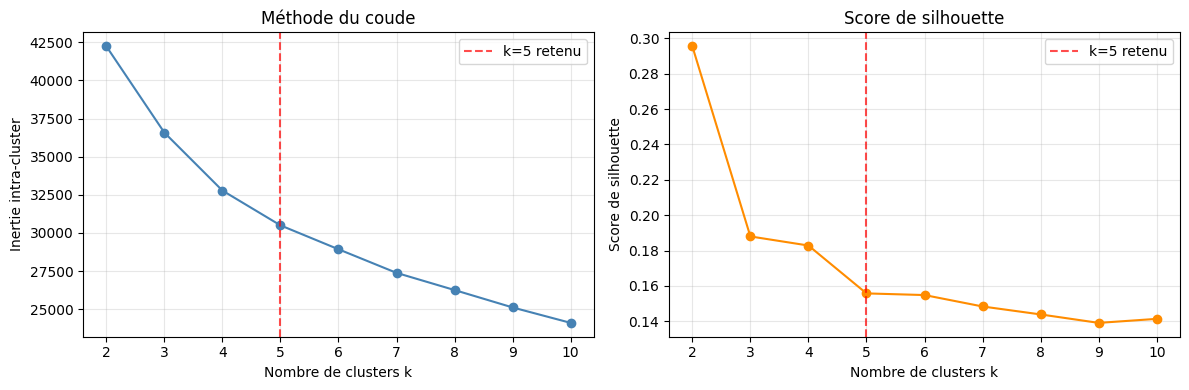


k=5 retenu — compromis interprétabilité / cohésion.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Coude
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue')
axes[0].axvline(x=N_CLUSTERS, color='red', linestyle='--', alpha=0.7, label=f'k={N_CLUSTERS} retenu')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie intra-cluster')
axes[0].set_title('Méthode du coude')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(list(k_range), silhouettes, 'o-', color='darkorange')
axes[1].axvline(x=N_CLUSTERS, color='red', linestyle='--', alpha=0.7, label=f'k={N_CLUSTERS} retenu')
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score de silhouette')
axes[1].set_title('Score de silhouette')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"\nk={N_CLUSTERS} retenu — compromis interprétabilité / cohésion.")

## 4. Entraînement K-Means (k = 5)

**Paramètres :**
- `n_clusters=5`
- `random_state=42` — résultat reproductible
- `n_init=10` — 10 initialisations aléatoires, meilleure solution retenue (inertie minimale)

In [8]:
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
raw_labels = km_final.fit_predict(X)

print(f"Inertie finale : {km_final.inertia_:,.0f}")
print(f"Itérations     : {km_final.n_iter_}")
print(f"\nDistribution brute (avant tri) :")
unique, counts = np.unique(raw_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  cluster {u} : {c:,} communes ({100*c/len(raw_labels):.1f}%)")

Inertie finale : 108,247
Itérations     : 19

Distribution brute (avant tri) :
  cluster 0 : 3,420 communes (9.8%)
  cluster 1 : 6,657 communes (19.2%)
  cluster 2 : 6,866 communes (19.8%)
  cluster 3 : 10,839 communes (31.2%)
  cluster 4 : 6,947 communes (20.0%)


## 5. Tri des clusters par score APL composite

K-Means attribue des labels arbitraires (0 à 4). Pour obtenir un ordre stable et interprétable  
(0 = le pire APL, 4 = le meilleur), les clusters sont triés par **score APL composite ascendant**.

Score APL composite = `0.35×méd + 0.15×dent + 0.25×inf + 0.20×kiné + 0.05×sf` (z-scores)

In [9]:
centers = km_final.cluster_centers_  # shape (5, 7)

# Score APL composite par cluster (sur les 5 premières features = APL)
apl_scores = centers[:, :5] @ APL_WEIGHTS
print("Score APL composite brut par cluster :")
for i, s in enumerate(apl_scores):
    print(f"  cluster brut {i} : {s:.4f}")

# Tri : ordre ascendant du score APL → cluster 0 = désert, cluster 4 = pôle
sorted_order = np.argsort(apl_scores)  # index bruts triés
label_mapping = {old: new for new, old in enumerate(sorted_order)}
print(f"\nMapping : {label_mapping}")

df_clean['cluster'] = np.array([label_mapping[l] for l in raw_labels])

Score APL composite brut par cluster :
  cluster brut 0 : 1.5782
  cluster brut 1 : -0.9518
  cluster brut 2 : 0.5151
  cluster brut 3 : -0.2817
  cluster brut 4 : 0.0540

Mapping : {np.int64(1): 0, np.int64(3): 1, np.int64(4): 2, np.int64(2): 3, np.int64(0): 4}


## 6. Profils des clusters

In [10]:
CLUSTER_NAMES = {
    0: 'Déserts médicaux',
    1: 'APL fragile',
    2: 'APL moyen',
    3: 'APL bon',
    4: 'Pôles de santé',
}

rows = []
for i in range(N_CLUSTERS):
    sub = df_clean[df_clean['cluster'] == i]
    old_idx = sorted_order[i]
    c = centers[old_idx]
    rows.append({
        'Cluster': i,
        'Profil': CLUSTER_NAMES[i],
        'Communes': len(sub),
        'Population': int(sub['population'].sum()),
        'Score APL': round(float((c[:5] * APL_WEIGHTS).sum()), 3),
        'Médecins (σ)': round(float(c[0]), 3),
        'Dentistes (σ)': round(float(c[1]), 3),
        'Infirmiers (σ)': round(float(c[2]), 3),
        'Kinés (σ)': round(float(c[3]), 3),
        'Sages-femmes (σ)': round(float(c[4]), 3),
        'Urbanité (σ)': round(float(c[5]), 3),
        'Besoins (σ)': round(float(c[6]), 3),
    })

df_profils = pd.DataFrame(rows)
df_profils

,Cluster,Profil,Communes,Population,Score APL,Médecins (σ),Dentistes (σ),Infirmiers (σ),Kinés (σ),Sages-femmes (σ),Urbanité (σ),Besoins (σ)
0,0,Déserts médicaux,6657,3088979,-0.952,-1.120,-0.973,-0.791,-0.884,-0.789,-0.780,0.250
1,1,APL fragile,10839,6677081,-0.282,-0.149,-0.398,-0.252,-0.444,-0.362,-0.712,-0.735
2,2,APL moyen,6947,18608318,0.054,-0.046,0.180,-0.011,0.163,0.270,-0.451,1.099
3,3,APL bon,6866,12096841,0.515,0.638,0.575,0.421,0.378,0.491,-0.501,-0.523
4,4,Pôles de santé,3420,21838082,1.578,1.445,1.597,1.497,2.007,1.141,-0.141,0.639


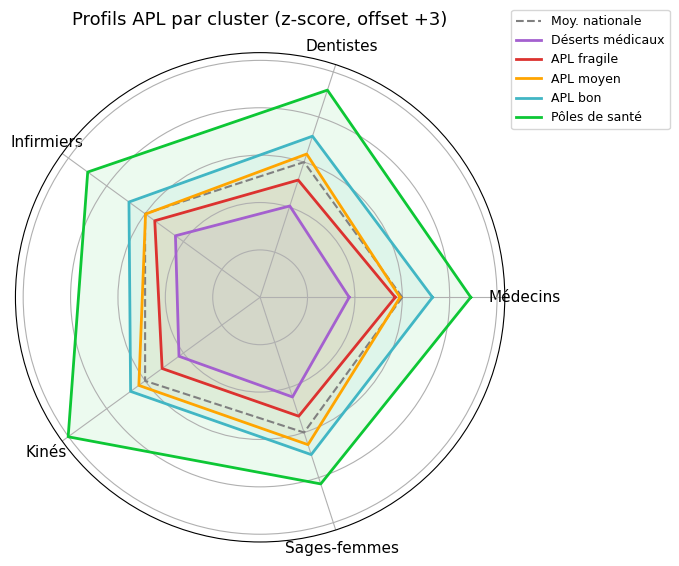

In [11]:
# Visualisation radar des profils APL
import matplotlib.pyplot as plt
import matplotlib

APL_LABELS = ['Médecins', 'Dentistes', 'Infirmiers', 'Kinés', 'Sages-femmes']
CLUSTER_COLORS = ['#a460cf', '#dc322f', '#ffa500', '#41b6c4', '#0dc735']

N = len(APL_LABELS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Anneau moyenne nationale (z=0, décalage +3 pour positiver)
offset = 3
ref = [offset] * (N + 1)
ax.plot(angles, ref, color='grey', linewidth=1.5, linestyle='--', label='Moy. nationale')

for i in range(N_CLUSTERS):
    old_idx = sorted_order[i]
    vals = [float(centers[old_idx, j]) + offset for j in range(5)]
    vals += vals[:1]
    ax.plot(angles, vals, color=CLUSTER_COLORS[i], linewidth=2, label=CLUSTER_NAMES[i])
    ax.fill(angles, vals, color=CLUSTER_COLORS[i], alpha=0.08)

ax.set_thetagrids(np.degrees(angles[:-1]), APL_LABELS, fontsize=11)
ax.set_yticklabels([])
ax.set_title("Profils APL par cluster (z-score, offset +3)", pad=20, fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

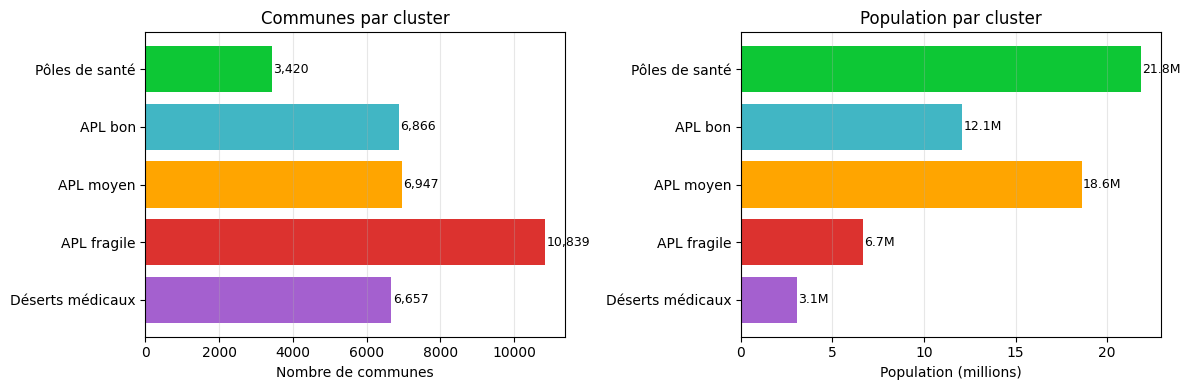

In [12]:
# Distribution des communes et population par cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

noms = [CLUSTER_NAMES[i] for i in range(N_CLUSTERS)]
nb_communes = df_profils['Communes'].values
population  = df_profils['Population'].values / 1e6  # en millions

axes[0].barh(noms, nb_communes, color=CLUSTER_COLORS)
axes[0].set_xlabel('Nombre de communes')
axes[0].set_title('Communes par cluster')
axes[0].grid(axis='x', alpha=0.3)
for j, v in enumerate(nb_communes):
    axes[0].text(v + 50, j, f'{v:,}', va='center', fontsize=9)

axes[1].barh(noms, population, color=CLUSTER_COLORS)
axes[1].set_xlabel('Population (millions)')
axes[1].set_title('Population par cluster')
axes[1].grid(axis='x', alpha=0.3)
for j, v in enumerate(population):
    axes[1].text(v + 0.05, j, f'{v:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Sauvegarde du fichier de clusters

In [13]:
df_output = df_clean[['code_insee', 'cluster']].copy()
df_output['cluster'] = df_output['cluster'].astype(np.int8)

print(f"Lignes exportées : {len(df_output):,}")
print(df_output.head())

df_output.to_parquet(OUTPUT_FILE, index=False)
print(f"\nFichier écrit : {OUTPUT_FILE}")

Lignes exportées : 34,729
  code_insee  cluster
0      01001        2
1      01002        2
2      01004        4
3      01005        2
4      01006        0

Fichier écrit : ../data/processed/data/commune/commune_clusters.parquet


## 8. Récapitulatif de la méthodologie

| Étape | Détail |
|---|---|
| **Algorithme** | K-Means |
| **k** | 5 (méthode du coude + silhouette) |
| **n_init** | 10 initialisations, meilleure retenue |
| **random_state** | 42 (reproductible) |
| **Variables** | 5 APL standardisés + urbanité + besoins (7 features) |
| **Échelle** | Z-scores (μ=0, σ=1) — pas de normalisation supplémentaire |
| **Tri** | Score APL composite ascendant → 0=Désert, 4=Pôle |
| **Score APL composite** | 0.35×méd + 0.15×dent + 0.25×inf + 0.20×kiné + 0.05×sf |
| **Output** | `commune_clusters.parquet` (code_insee, cluster) |

### Noms des clusters

| Cluster | Nom | Couleur |
|---|---|---|
| 0 | Déserts médicaux | Violet |
| 1 | APL fragile | Rouge |
| 2 | APL moyen | Orange |
| 3 | APL bon | Cyan |
| 4 | Pôles de santé | Vert |